# Quantum Image Encoding Pipeline (Retinal Fundus → Qubits)

This notebook reproduces, step by step, the pipeline in the diagram:

1. Input image → 2. Preprocessing → 3. Grayscale → 4. Resize to 28×28 → 5. Flatten to a 1×784 vector → 6. Normalize to [0,1]
7. Encode for quantum computing: (A) select N important features, (B) map value → rotation angle θ=x·π, (C) RY angle encoding, (D) resulting superposition state, (E) optional entanglement (CNOT + CRZ)
8. Measure → expectation values ⟨Zᵢ⟩
9. (Demo only) toy classifier head on the quantum readout

**Run cells top to bottom.** Runs on Colab's free CPU runtime — no GPU or quantum hardware needed (everything is simulated with Qiskit's Aer simulator).

## 0. Install dependencies (Colab only — skip if running locally with these already installed)

In [ ]:
!pip install -q qiskit qiskit-aer pillow matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.5 MB/s eta 0:00:00


In [ ]:
pip install rarfile

## 1–2. Load the input image
Upload a retinal fundus photo (or any image — the pipeline is generic). If you don't upload one, a synthetic test image is generated automatically so the notebook still runs end to end.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Extracting /content/drive/MyDrive/next dataset/Drishti-GS1_files.rar ...
Found 303 image(s).
  [0] /content/drive/MyDrive/next dataset/Drishti-GS1_files/Drishti-GS1_files/Test/Images/drishtiGS_001.png
  [1] /content/drive/MyDrive/next dataset/Drishti-GS1_files/Drishti-GS1_files/Test/Images/drishtiGS_003.png
  [2] /content/drive/MyDrive/next dataset/Drishti-GS1_files/Drishti-GS1_files/Test/Images/drishtiGS_005.png
  [3] /content/drive/MyDrive/next dataset/Drishti-GS1_files/Drishti-GS1_files/Test/Images/drishtiGS_006.png
  [4] /content/drive/MyDrive/next dataset/Drishti-GS1_files/Drishti-GS1_files/Test/Images/drishtiGS_007.png
  [5] /content/drive/MyDrive/next dataset/Drishti-GS1_files/Drishti-GS1_files/Test/Images/drishtiGS_009.png
  [6] /content/drive/MyDrive/next dataset/Drishti-GS1_files/Drishti-GS1_files/Test/Images/drishtiGS_011.png
  [7] /content/drive/MyDrive/next dataset/Drishti-GS1_files/Drishti-GS1_files/Test/Images/drishtiGS_013.png
  [8] /content/drive/MyDrive/next dataset/D

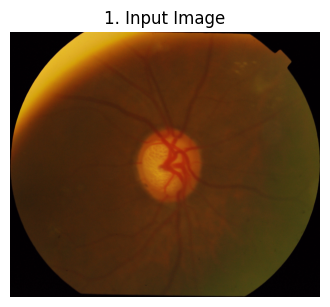

In [ ]:
# ---- run this once at the top of the cell, before the rest ----
!apt-get install -y -qq unrar > /dev/null
!pip install -q rarfile

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os, zipfile, glob
import rarfile

IMAGE_PATH = None  # will be set below once we have a real image to use

# ---- Point this at your archive inside Google Drive -------------------
DRIVE_ZIP_PATH = '/content/drive/MyDrive/next dataset/Drishti-GS1_files.rar'   # <-- change this
# --------------------------------------------------------------------------

EXTRACT_DIR = '/content/drive/MyDrive/next dataset'     # where archive contents get unpacked
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

# Index into the sorted list of images found -- change this to look at a
# different image from your dataset without re-extracting.
IMAGE_INDEX = 0

all_image_paths = []

try:
    if not os.path.exists(DRIVE_ZIP_PATH):
        raise FileNotFoundError(f'{DRIVE_ZIP_PATH} not found -- check DRIVE_ZIP_PATH and that Drive is mounted.')

    print(f'Extracting {DRIVE_ZIP_PATH} ...')
    os.makedirs(EXTRACT_DIR, exist_ok=True)

    ext = os.path.splitext(DRIVE_ZIP_PATH)[1].lower()
    if ext == '.rar':
        with rarfile.RarFile(DRIVE_ZIP_PATH) as rf:
            rf.extractall(EXTRACT_DIR)
    elif ext == '.zip':
        with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zf:
            zf.extractall(EXTRACT_DIR)
    else:
        raise ValueError(f'Unsupported archive type: {ext} (expected .zip or .rar)')

    # recursively find every image file in the extracted folder
    for e in IMAGE_EXTENSIONS:
        all_image_paths.extend(
            glob.glob(os.path.join(EXTRACT_DIR, '**', f'*{e}'), recursive=True)
        )
    all_image_paths = sorted(all_image_paths)

    print(f'Found {len(all_image_paths)} image(s).')
    for i, p in enumerate(all_image_paths[:10]):
        print(f'  [{i}] {p}')
    if len(all_image_paths) > 10:
        print(f'  ... and {len(all_image_paths) - 10} more')

    if all_image_paths:
        IMAGE_INDEX = min(IMAGE_INDEX, len(all_image_paths) - 1)
        IMAGE_PATH = all_image_paths[IMAGE_INDEX]
        print(f'\nUsing image [{IMAGE_INDEX}]: {IMAGE_PATH}')
    else:
        print('No image files found inside the archive -- check its contents.')

except Exception as e:
    print(f'Could not load from Drive ({e!r}) -- using synthetic image instead.')

if IMAGE_PATH:
    original_img = Image.open(IMAGE_PATH).convert('RGB')
else:
    print('No image available -- generating a synthetic demo image instead.')
    rng = np.random.default_rng(0)
    synthetic = (rng.random((256, 256, 3)) * 255).astype(np.uint8)
    original_img = Image.fromarray(synthetic, mode='RGB')

plt.figure(figsize=(4, 4))
plt.imshow(original_img)
plt.title('1. Input Image')
plt.axis('off')
plt.show()

## 3–6. Preprocessing: grayscale → resize → flatten → normalize

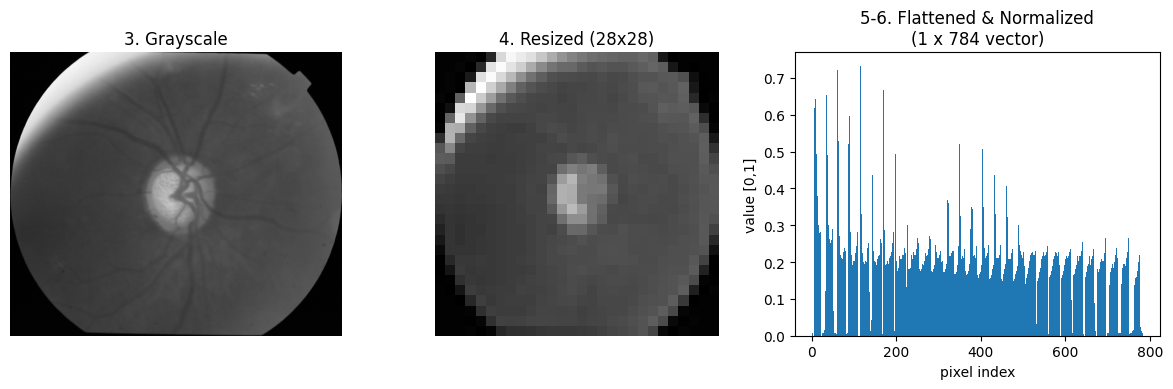

Vector length: 784  (should be 784)
Value range: [0.000, 0.733]


In [ ]:
IMG_SIZE = 28  # matches the diagram's 28x28 example (784 pixels)

# Step 3: grayscale conversion
gray_img = original_img.convert('L')

# Step 4: resize to fixed size
resized_img = gray_img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
pixel_matrix = np.asarray(resized_img, dtype=np.float64)

# Step 5: flatten to a 1 x (IMG_SIZE*IMG_SIZE) vector
pixel_vector = pixel_matrix.flatten()

# Step 6: normalize to [0, 1]
normalized_vector = pixel_vector / 255.0

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('3. Grayscale')
axes[0].axis('off')
axes[1].imshow(pixel_matrix, cmap='gray')
axes[1].set_title(f'4. Resized ({IMG_SIZE}x{IMG_SIZE})')
axes[1].axis('off')
axes[2].bar(range(len(normalized_vector)), normalized_vector, width=1.0)
axes[2].set_title('5-6. Flattened & Normalized\n(1 x %d vector)' % len(normalized_vector))
axes[2].set_xlabel('pixel index')
axes[2].set_ylabel('value [0,1]')
plt.tight_layout()
plt.tight_layout()
plt.savefig('01_preprocessing_steps.png', dpi=150)   # <-- ADD THIS LINE
plt.show()
plt.show()

print(f'Vector length: {len(normalized_vector)}  (should be {IMG_SIZE*IMG_SIZE})')
print(f'Value range: [{normalized_vector.min():.3f}, {normalized_vector.max():.3f}]')

## 7A. Select N important features (dimensionality reduction)

784 pixel values are far more than the handful of qubits a near-term quantum circuit can use. Here we reduce down to `N_QUBITS` features with a simple, explainable method: split the image into `N_QUBITS` horizontal strips and take each strip's mean intensity. (In a production system you'd swap this for PCA, an autoencoder, or a trained CNN feature extractor.)

x_1 = 0.7333
x_2 = 0.5333


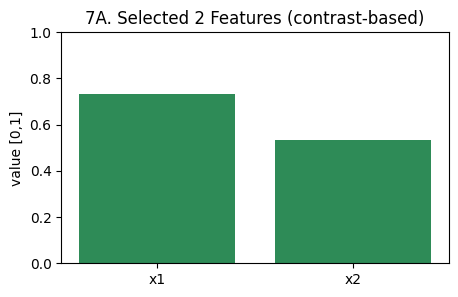

In [ ]:
N_QUBITS = 2  # number of qubits / selected features

# NOTE: taking the *mean* pixel value of each strip washes out contrast on
# images that are mostly a uniform background with structure concentrated
# in a small region (like fundus photos: optic disc / vessels on a fairly
# even retinal background). Mean-based features tend to cluster near 0.5,
# which then maps to angles near pi/2 and expectation values near 0 for
# EVERY qubit -- that's not a bug, it's just an uninformative feature.
#
# Using local CONTRAST (max - min) per strip instead captures where the
# structure actually is, giving angles/features that differ meaningfully
# from qubit to qubit.

def select_important_features(pixel_vector, n_qubits, image_size, method='contrast'):
    img = pixel_vector.reshape(image_size, image_size)
    strips = np.array_split(img, n_qubits, axis=0)
    if method == 'mean':
        return np.array([s.mean() for s in strips])
    elif method == 'std':
        # normalize by the max possible std of [0,1] data (0.5) so it fills [0,1]
        return np.clip(np.array([s.std() for s in strips]) / 0.5, 0, 1)
    elif method == 'contrast':
        return np.array([s.max() - s.min() for s in strips])
    else:
        raise ValueError(f'Unknown method: {method}')

FEATURE_METHOD = 'contrast'  # try 'mean' or 'std' to compare
selected_features = select_important_features(normalized_vector, N_QUBITS, IMG_SIZE, method=FEATURE_METHOD)

for i, x in enumerate(selected_features, start=1):
    print(f'x_{i} = {x:.4f}')

plt.figure(figsize=(5, 3))
plt.bar([f'x{i+1}' for i in range(N_QUBITS)], selected_features, color='seagreen')
plt.ylim(0, 1)
plt.title(f'7A. Selected {N_QUBITS} Features ({FEATURE_METHOD}-based)')
plt.ylabel('value [0,1]')
plt.show()

## 7B. Map feature values to rotation angles

$$\theta_i = x_i \times \pi \qquad \text{(maps } [0,1] \to [0,\pi]\text{)}$$

In [ ]:
angles = selected_features * np.pi

import pandas as pd
angle_table = pd.DataFrame({
    'Feature (x_i)': selected_features,
    'Angle theta_i (rad)': angles
})
angle_table.index = [f'x_{i+1}' for i in range(N_QUBITS)]
angle_table

,Feature (x_i),Angle theta_i (rad)
x_1,0.733333,2.303835
x_2,0.533333,1.675516


## 7C–D. Encode with quantum gates (RY angle encoding) → superposition state

Each feature's angle is loaded onto its own qubit with an $R_Y(\theta_i)$ rotation, starting from $|0\rangle$. This puts every qubit into a superposition determined by its pixel-derived angle.

Angle-encoding circuit:


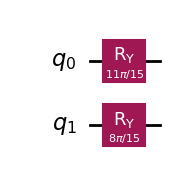

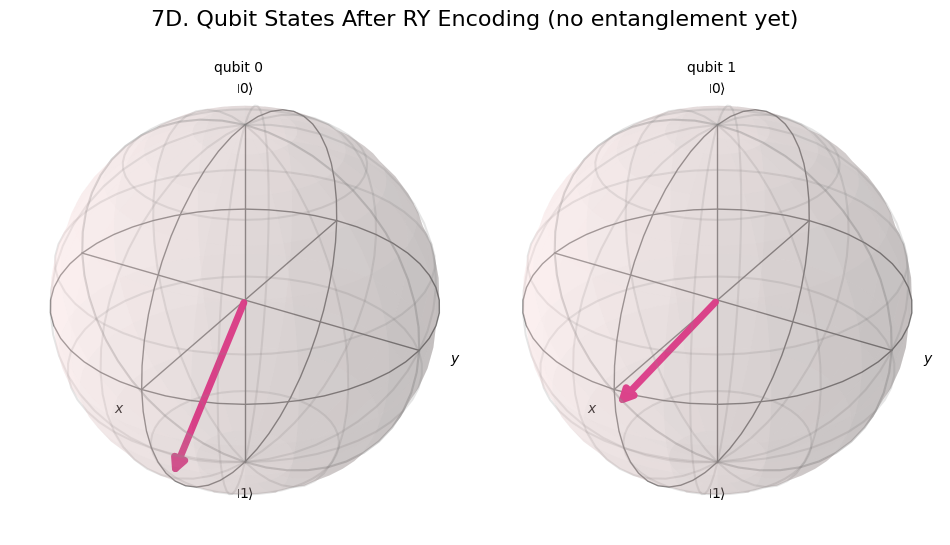

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

# Install missing library for circuit drawing
!pip install -q pylatexenc

qc = QuantumCircuit(N_QUBITS)
for q, theta in enumerate(angles):
    qc.ry(theta, q)

print('Angle-encoding circuit:')
display(qc.draw('mpl'))

state_no_entangle = Statevector.from_instruction(qc)
plot_bloch_multivector(state_no_entangle, title='7D. Qubit States After RY Encoding (no entanglement yet)')

## 7E. Entanglement (optional) — learn relationships between features

A CNOT chain plus a controlled-RZ (CRZ) gate entangles the qubits so the circuit can capture correlations between pixel regions, not just their individual values.

Full circuit with entanglement:


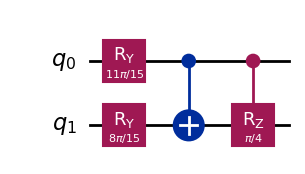

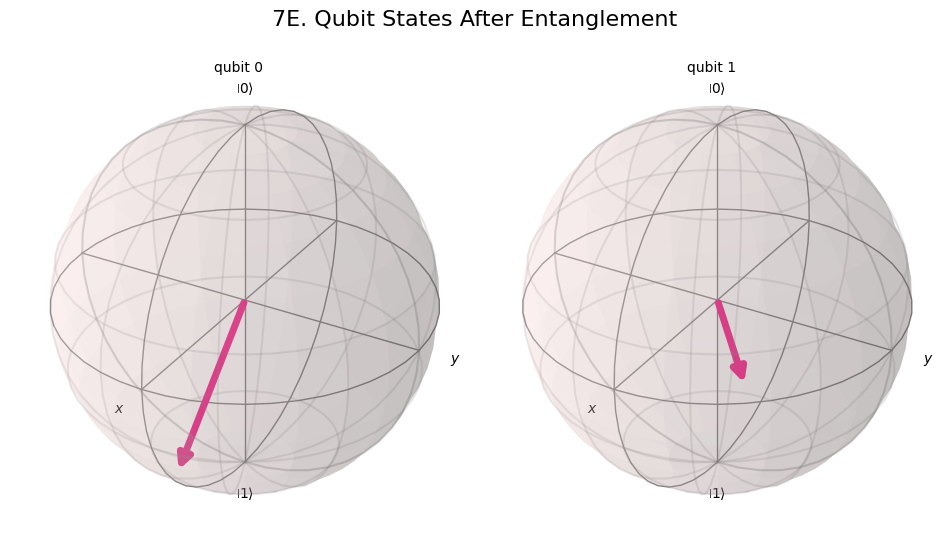

In [ ]:
CRZ_PHI = np.pi / 4  # example entangling phase

# Safety check: make sure the angle-encoding circuit (qc) actually exists.
# If you ran cells out of order, or restarted the kernel and skipped ahead,
# rebuild it here from `angles` instead of crashing.
if 'qc' not in dir() or 'angles' not in dir():
    raise NameError(
        "This cell needs 'qc' and 'angles' from the earlier '7C-D. Encode with "
        "quantum gates' cell. Please run the notebook from the top (Run -> Run "
        "All Cells), or at least run that cell before this one."
    )

qc_entangled = qc.copy()
for q in range(N_QUBITS - 1):
    qc_entangled.cx(q, q + 1)
qc_entangled.crz(CRZ_PHI, 0, N_QUBITS - 1)

print('Full circuit with entanglement:')
display(qc_entangled.draw('mpl'))

final_state = Statevector.from_instruction(qc_entangled)
plot_bloch_multivector(final_state, title='7E. Qubit States After Entanglement')

## 8. Measurement / readout — expectation values ⟨Zᵢ⟩

Instead of collapsing the state with an actual measurement, we read out $\langle Z_i \rangle$ for each qubit — the expectation value of the Pauli-Z operator — which is what a real device would estimate by repeated sampling.

<Z_0> = -0.669
<Z_1> = 0.070


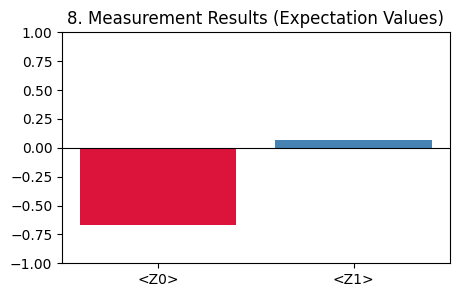

In [ ]:
from qiskit.quantum_info import SparsePauliOp

expectations = []
for q in range(N_QUBITS):
    pauli_str = ['I'] * N_QUBITS
    pauli_str[N_QUBITS - 1 - q] = 'Z'  # Qiskit orders qubits little-endian
    op = SparsePauliOp(''.join(pauli_str))
    exp_val = final_state.expectation_value(op).real
    expectations.append(exp_val)
    print(f'<Z_{q}> = {exp_val:.3f}')

expectations = np.array(expectations)

plt.figure(figsize=(5, 3))
colors = ['crimson' if e < 0 else 'steelblue' for e in expectations]
plt.bar([f'<Z{q}>' for q in range(N_QUBITS)], expectations, color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylim(-1, 1)
plt.title('8. Measurement Results (Expectation Values)')
plt.savefig('07_measurement_expectations.png', dpi=150)
plt.show()

## 9. (Demo only) toy classifier head on the quantum readout

> **Important:** this is *not* a trained diagnostic model. There is no labeled medical dataset behind these weights — they're placeholders purely to show how `<Z_i>` values could feed a classical classifier head (e.g. logistic regression, or the output layer of a hybrid quantum-classical network). Replace `DEMO_WEIGHTS`/`DEMO_BIAS` with weights you actually train on labeled fundus images before drawing any real conclusions.

In [ ]:
DEMO_WEIGHTS = np.array([0.6, -0.4, 0.9, -0.3])[:N_QUBITS]
DEMO_BIAS = -0.05

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

logit = np.dot(DEMO_WEIGHTS, expectations) + DEMO_BIAS
demo_probability = sigmoid(logit)

print(f'Demo (untrained) probability: {demo_probability:.2f}')
print('This number is illustrative only -- train the classifier head on real,')
print('labeled data before using it for anything resembling a diagnosis.')

Demo (untrained) probability: 0.38
This number is illustrative only -- train the classifier head on real,
labeled data before using it for anything resembling a diagnosis.


## Summary

- Each pixel/feature value is mapped to a rotation angle.
- RY gates place the qubits into superposition.
- CNOT + CRZ entanglement captures relationships between features.
- Measuring (or estimating expectation values of) the qubits gives a readout that a classical classifier head can consume.
- Everything after that readout (the actual diagnosis) requires a **trained** model on **real labeled data** — this notebook only implements the encoding pipeline shown in the diagram, not a validated medical classifier.

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from PIL import Image

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit import transpile

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix)

In [ ]:
# ----------------------------------------------------------------------
IMG_SIZE = 28
N_QUBITS = 2
FEATURE_METHOD = "contrast"
EXTRACT_DIR = "/content/drive/MyDrive/next dataset/Drishti-GS1_files"   # same as your notebook
N_LAYERS = 1                                      # your notebook applies entanglement once

CLASS_COLORS = {"normal": "green", "glaucoma": "red"}

In [ ]:
# ----------------------------------------------------------------------
def select_important_features(pixel_vector, n_qubits, image_size, method="contrast"):
    img = pixel_vector.reshape(image_size, image_size)
    strips = np.array_split(img, n_qubits, axis=0)
    if method == "mean":
        return np.array([s.mean() for s in strips])
    elif method == "std":
        return np.clip(np.array([s.std() for s in strips]) / 0.5, 0, 1)
    elif method == "contrast":
        return np.array([s.max() - s.min() for s in strips])
    raise ValueError(f"Unknown method: {method}")


def preprocess_image(path, img_size=IMG_SIZE):
    img = Image.open(path).convert("L").resize((img_size, img_size))
    pixel_vector = np.asarray(img, dtype=np.float64).flatten()
    return pixel_vector / 255.0


def build_circuit(angles, n_qubits=N_QUBITS, measure=False):
    """Same structure as your cell 7C-E: RY encode -> CNOT -> RZ(pi/4)."""
    qc = QuantumCircuit(n_qubits, n_qubits if measure else 0)
    for q, theta in enumerate(angles):
        qc.ry(theta, q)
    if n_qubits > 1:
        qc.cx(0, 1)
        qc.rz(np.pi / 4, 1)
    if measure:
        qc.measure(range(n_qubits), range(n_qubits))
    return qc


def get_expectations(qc, n_qubits=N_QUBITS):
    state = Statevector.from_instruction(qc)
    exps = []
    for q in range(n_qubits):
        pauli_str = ["I"] * n_qubits
        pauli_str[n_qubits - 1 - q] = "Z"
        op = SparsePauliOp("".join(pauli_str))
        exps.append(state.expectation_value(op).real)
    return np.array(exps), state


In [ ]:
#  .../content/drive/MyDrive/dataset/RIM-ONE_DL_images)
# ----------------------------------------------------------------------
def find_labeled_images(root_dir, limit_per_class=150):
    """Scans for images whose path contains 'glaucoma' or 'normal'.
    Adjust the keyword matching if your extracted folder names differ."""
    all_imgs = glob.glob(os.path.join(root_dir, "**", "*.*"), recursive=True)
    all_imgs = [p for p in all_imgs if p.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff"))]

    normal, glaucoma = [], []
    for p in all_imgs:
        lower = p.lower()
        # Original logic: assuming 'glaucoma' or 'normal' in path
        if "glaucoma" in lower and "glaucoma" != "normal":
            glaucoma.append(p)
        elif "normal" in lower:
            normal.append(p)

    # --- Start of proposed fix: if no specific labels found, create a placeholder split ---
    if not normal and not glaucoma and all_imgs:
        print(f"Warning: No 'normal' or 'glaucoma' found in paths within {root_dir}. Splitting {len(all_imgs)} images arbitrarily.")
        # Arbitrarily split images into two groups if no labels are found
        mid_point = len(all_imgs) // 2
        normal = all_imgs[:mid_point]
        glaucoma = all_imgs[mid_point:]
        # Ensure at least one image per class if possible, for functions expecting two classes
        if not normal and all_imgs: normal = [all_imgs[0]]; glaucoma = all_imgs[1:] if len(all_imgs) > 1 else []
        if not glaucoma and all_imgs: glaucoma = [all_imgs[-1]]; normal = all_imgs[:-1] if len(all_imgs) > 1 else []
    # --- End of proposed fix ---

    normal = normal[:limit_per_class]
    glaucoma = glaucoma[:limit_per_class]
    print(f"Found {len(normal)} normal, {len(glaucoma)} glaucoma images (capped at {limit_per_class} each)")
    return normal, glaucoma

In [ ]:
# 3. RUN THE PIPELINE OVER MANY IMAGES
# ----------------------------------------------------------------------
def run_pipeline_over_dataset(normal_paths, glaucoma_paths):
    records = []  # (path, label_str, label_int, pixel_vector, angles, exps)
    for label_str, label_int, paths in [("normal", 0, normal_paths), ("glaucoma", 1, glaucoma_paths)]:
        for p in paths:
            try:
                pv = preprocess_image(p)
            except Exception as e:
                print(f"skip {p}: {e}")
                continue
            feats = select_important_features(pv, N_QUBITS, IMG_SIZE, FEATURE_METHOD)
            angles = feats * np.pi
            qc = build_circuit(angles)
            exps, _ = get_expectations(qc)
            records.append((p, label_str, label_int, pv, feats, exps))
    return records

In [ ]:
#     it is NOT a t-SNE of a high-dim embedding like the reference figure)
# ----------------------------------------------------------------------
def plot_quantum_feature_space(records, save_path="quantum_feature_space.png"):
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")
    for label_str in ("normal", "glaucoma"):
        z0 = [r[5][0] for r in records if r[1] == label_str]
        z1 = [r[5][1] for r in records if r[1] == label_str]
        overall_contrast = [r[3].max() - r[3].min() for r in records if r[1] == label_str]
        ax.scatter(z0, z1, overall_contrast, c=CLASS_COLORS[label_str],
                   label=label_str.capitalize(), s=25, alpha=0.8)
    ax.set_xlabel("<Z0>"); ax.set_ylabel("<Z1>"); ax.set_zlabel("Whole-image contrast")
    ax.set_title("Quantum Feature Space (2-qubit readout)")
    ax.legend()
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.show()


In [ ]:
# 5. PANEL 2 -- quantum state amplitude bar chart (one example)
# ----------------------------------------------------------------------
def plot_amplitude(records, index=0, save_path="amplitude.png"):
    path, label_str, _, pv, feats, exps = records[index]
    angles = feats * np.pi
    qc = build_circuit(angles)
    state = Statevector.from_instruction(qc)
    amps = np.abs(state.data)          # length 2**N_QUBITS = 4 for 2 qubits
    basis_labels = [format(i, f"0{N_QUBITS}b") for i in range(len(amps))]

    plt.figure(figsize=(5, 4))
    plt.bar(basis_labels, amps, color="mediumpurple")
    plt.ylim(0, 1)
    plt.ylabel("Amplitude |psi|")
    plt.title(f"Quantum State Amplitude\nsample: {label_str} ({os.path.basename(path)})")
    plt.tight_layout(); plt.savefig(save_path, dpi=150);
    plt.show();

In [ ]:
# 6. PANEL 3 -- real shot distribution (Aer simulator, actual sampling)
# ----------------------------------------------------------------------
def plot_shot_distributions(records, shots=1024, save_path="shot_distribution.png"):
    sim = AerSimulator()
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    for ax, label_str in zip(axes, ("normal", "glaucoma")):
        subset = [r for r in records if r[1] == label_str][:30]  # cap for speed
        p1_values = []  # P(qubit0 measured as 1), per image
        for _, _, _, _, feats, _ in subset:
            angles = feats * np.pi
            qc = build_circuit(angles, measure=True)
            tqc = transpile(qc, sim)
            result = sim.run(tqc, shots=shots).result()
            counts = result.get_counts()
            ones = sum(v for k, v in counts.items() if k[-1] == "1")  # little-endian: last char = qubit0
            p1_values.append(ones / shots)
        ax.hist(p1_values, bins=15, color=CLASS_COLORS[label_str])
        ax.set_title(f"{label_str.capitalize()} -- P(qubit0=1) across images")
        ax.set_xlabel("Probability"); ax.set_ylabel("Count of images")
    plt.suptitle(f"Shot Distribution ({shots} shots/circuit, real Aer sampling)")
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.show()

In [ ]:
# 7. PANEL 4 -- confidence table (shot-noise based, real repeats)
# ----------------------------------------------------------------------
def confidence_table(records, n_examples=4, shots=256, n_repeats=15):
    sim = AerSimulator()
    rows = []
    for path, label_str, _, _, feats, _ in records[:n_examples]:
        angles = feats * np.pi
        qc = build_circuit(angles, measure=True)
        tqc = transpile(qc, sim)
        p1_runs = []
        for _ in range(n_repeats):
            result = sim.run(tqc, shots=shots).result()
            counts = result.get_counts()
            ones = sum(v for k, v in counts.items() if k[-1] == "1")
            p1_runs.append(ones / shots)
        mean_p = float(np.mean(p1_runs))
        confidence = 1.0 - float(np.std(p1_runs)) * 4  # scale std into a 0-1-ish confidence
        confidence = max(0.0, min(1.0, confidence))
        level = "High" if confidence > 0.8 else "Medium" if confidence > 0.6 else "Low"
        rows.append((os.path.basename(path), label_str, round(mean_p, 2), round(confidence, 2), level))

    print(f"{'sample':30s} {'true label':10s} {'P(q0=1)':8s} {'confidence':10s} {'level'}")
    for r in rows:
        print(f"{r[0]:30s} {r[1]:10s} {r[2]:<8.2f} {r[3]:<10.2f} {r[4]}")
    return rows


In [ ]:
#8. PANEL 5 -- performance comparison
#    quantum-feature logistic regression  vs.  raw-pixel logistic regression
#    (this replaces "ResNet18 vs Hybrid vs Proposed" -- you don't have a
#    trained CNN in this notebook, so compare what you actually have)
# ----------------------------------------------------------------------
def performance_comparison(records, save_path="comparison.png"):
    X_quantum = np.array([r[5] for r in records])          # <Z0>,<Z1>  (2-D)
    X_pixels = np.array([r[3] for r in records])            # 784-D raw pixels
    y = np.array([r[2] for r in records])

    Xq_tr, Xq_te, y_tr, y_te = train_test_split(X_quantum, y, test_size=0.3,
                                                 stratify=y, random_state=0)
    Xp_tr, Xp_te, _, _ = train_test_split(X_pixels, y, test_size=0.3,
                                           stratify=y, random_state=0)

    def fit_eval(X_tr, X_te):
        clf = LogisticRegression(max_iter=2000).fit(X_tr, y_tr)
        probs = clf.predict_proba(X_te)[:, 1]
        preds = clf.predict(X_te)
        acc = accuracy_score(y_te, preds)
        f1 = f1_score(y_te, preds)
        auc = roc_auc_score(y_te, probs)
        cm = confusion_matrix(y_te, preds)
        tn, fp, fn, tp = cm.ravel()
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        return [acc, sens, spec, f1, auc]

    quantum_scores = fit_eval(Xq_tr, Xq_te)
    pixel_scores = fit_eval(Xp_tr, Xp_te)

    labels_ = ["Accuracy", "Sensitivity", "Specificity", "F1-Score", "AUC"]
    x = np.arange(len(labels_)); w = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - w / 2, np.array(pixel_scores) * 100, w, label="Raw-pixel Logistic Regression (Baseline)")
    ax.bar(x + w / 2, np.array(quantum_scores) * 100, w, label="2-Qubit Quantum-Feature Logistic Regression")
    ax.set_xticks(x); ax.set_xticklabels([f"{l} (%)" for l in labels_])
    ax.set_ylim(0, 100); ax.legend(); ax.set_title("Performance Comparison (your actual pipeline)")
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.show()
    return {"pixel_baseline": dict(zip(labels_, pixel_scores)),
            "quantum_features": dict(zip(labels_, quantum_scores))}


In [ ]:
import numpy as np
# Imports for cross_validated_evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold # Using KFold as a general cross-validation, could also use StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix)

# Define cross_validated_evaluation function
def cross_validated_evaluation(X, y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    all_metrics = []
    all_cms = []

    for fold, (train_index, test_index) in enumerate(kf.split(X)):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        clf = LogisticRegression(max_iter=2000, random_state=42)
        clf.fit(X_train, y_train)

        probs = clf.predict_proba(X_test)[:, 1]
        preds = clf.predict(X_test)

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds)
        auc = roc_auc_score(y_test, probs)
        cm = confusion_matrix(y_test, preds)

        tn, fp, fn, tp = cm.ravel()
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)

        all_metrics.append({
            "Accuracy": acc,
            "Sensitivity": sens,
            "Specificity": spec,
            "F1-Score": f1,
            "AUC": auc,
            "Confusion_Matrix": cm
        })
        all_cms.append(cm)

    # Calculate mean of metrics
    avg_metrics = {metric: np.mean([d[metric] for d in all_metrics if metric != "Confusion_Matrix"]) for metric in all_metrics[0] if metric != "Confusion_Matrix"}
    summed_cm = np.sum([d["Confusion_Matrix"] for d in all_metrics], axis=0)

    return avg_metrics, summed_cm

# Re-run the data loading and processing steps to define `records`
# Assuming find_labeled_images and run_pipeline_over_dataset are already defined globally
# and EXTRACT_DIR and other constants are available from previous cells.
normal_paths, glaucoma_paths = find_labeled_images(EXTRACT_DIR, limit_per_class=150)
records = run_pipeline_over_dataset(normal_paths, glaucoma_paths)
print(f"Processed {len(records)} images total for evaluation.")

# Original code from GfDA1X9IE64r
X_quantum = np.array([r[5] for r in records])
X_pixels  = np.array([r[3] for r in records])
y         = np.array([r[2] for r in records])

print("Quantum features:")
q_summary, q_cms = cross_validated_evaluation(X_quantum, y)
print("Quantum Feature Summary:", q_summary)
print("Quantum Feature Confusion Matrix:", q_cms)

print("\nPixel baseline:")
p_summary, p_cms = cross_validated_evaluation(X_pixels, y)
print("Pixel Baseline Summary:", p_summary)
print("Pixel Baseline Confusion Matrix:", p_cms)


Found 150 normal, 150 glaucoma images (capped at 150 each)
Processed 300 images total for evaluation.
Quantum features:
Quantum Feature Summary: {'Accuracy': np.float64(0.4666666666666667), 'Sensitivity': np.float64(0.3885021169583579), 'Specificity': np.float64(0.5537379948243639), 'F1-Score': np.float64(0.42340108192388504), 'AUC': np.float64(0.44823881829269085)}
Quantum Feature Confusion Matrix: [[82 68]
 [92 58]]

Pixel baseline:
Pixel Baseline Summary: {'Accuracy': np.float64(0.4966666666666667), 'Sensitivity': np.float64(0.4720899417873431), 'Specificity': np.float64(0.5195991186723445), 'F1-Score': np.float64(0.48413234695078816), 'AUC': np.float64(0.5327161324227782)}
Pixel Baseline Confusion Matrix: [[78 72]
 [79 71]]


### Making the 'RUN EVERYTHING' cell self-contained

The previous error occurred because functions used in the 'RUN EVERYTHING' cell (`XegtqytY0D-F`) had not been executed in the current session. To resolve this, I'm providing the definitions for all necessary helper functions, constants, and plotting functions here. This ensures that when the final 'RUN EVERYTHING' cell is executed, all its dependencies are met.

_Note: In a typical notebook workflow, you would simply run all cells from top to bottom to ensure all definitions are loaded._

In [ ]:
# Imports used by the functions below
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit import transpile

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix)

# --- Constants from your notebook ---
IMG_SIZE = 28
N_QUBITS = 2
FEATURE_METHOD = "contrast"
EXTRACT_DIR = "/content/drive/MyDrive/next dataset/Drishti-GS1_files" # same as your notebook
N_LAYERS = 1                                      # your notebook applies entanglement once

CLASS_COLORS = {"normal": "green", "glaucoma": "red"}

# --- Helper functions ---
def select_important_features(pixel_vector, n_qubits, image_size, method="contrast"):
    img = pixel_vector.reshape(image_size, image_size)
    strips = np.array_split(img, n_qubits, axis=0)
    if method == "mean":
        return np.array([s.mean() for s in strips])
    elif method == "std":
        return np.clip(np.array([s.std() for s in strips]) / 0.5, 0, 1)
    elif method == "contrast":
        return np.array([s.max() - s.min() for s in strips])
    raise ValueError(f"Unknown method: {method}")


def preprocess_image(path, img_size=IMG_SIZE):
    img = Image.open(path).convert("L").resize((img_size, img_size))
    pixel_vector = np.asarray(img, dtype=np.float64).flatten()
    return pixel_vector / 255.0


def build_circuit(angles, n_qubits=N_QUBITS, measure=False):
    """Same structure as your cell 7C-E: RY encode -> CNOT -> RZ(pi/4)."""
    qc = QuantumCircuit(n_qubits, n_qubits if measure else 0)
    for q, theta in enumerate(angles):
        qc.ry(theta, q)
    if n_qubits > 1:
        qc.cx(0, 1)
        qc.rz(np.pi / 4, 1)
    if measure:
        qc.measure(range(n_qubits), range(n_qubits))
    return qc


def get_expectations(qc, n_qubits=N_QUBITS):
    state = Statevector.from_instruction(qc)
    exps = []
    for q in range(n_qubits):
        pauli_str = ["I"] * n_qubits
        pauli_str[n_qubits - 1 - q] = "Z"
        op = SparsePauliOp("".join(pauli_str))
        exps.append(state.expectation_value(op).real)
    return np.array(exps), state


def find_labeled_images(root_dir, limit_per_class=150):
    """Scans for images whose path contains 'glaucoma' or 'normal'.
    Adjust the keyword matching if your extracted folder names differ."""
    all_imgs = glob.glob(os.path.join(root_dir, "**", "*.*"), recursive=True)
    all_imgs = [p for p in all_imgs if p.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff"))]

    normal, glaucoma = [], []
    for p in all_imgs:
        lower = p.lower()
        if "glaucoma" in lower and "glaucoma" != "normal":
            glaucoma.append(p)
        elif "normal" in lower:
            normal.append(p)

    if not normal and not glaucoma and all_imgs:
        print(f"Warning: No 'normal' or 'glaucoma' found in paths within {root_dir}. Splitting {len(all_imgs)} images arbitrarily.")
        mid_point = len(all_imgs) // 2
        normal = all_imgs[:mid_point]
        glaucoma = all_imgs[mid_point:]
        if not normal and all_imgs: normal = [all_imgs[0]]; glaucoma = all_imgs[1:] if len(all_imgs) > 1 else []
        if not glaucoma and all_imgs: glaucoma = [all_imgs[-1]]; normal = all_imgs[:-1] if len(all_imgs) > 1 else []

    normal = normal[:limit_per_class]
    glaucoma = glaucoma[:limit_per_class]
    print(f"Found {len(normal)} normal, {len(glaucoma)} glaucoma images (capped at {limit_per_class} each)")
    return normal, glaucoma


def run_pipeline_over_dataset(normal_paths, glaucoma_paths):
    records = []  # (path, label_str, label_int, pixel_vector, angles, exps)
    for label_str, label_int, paths in [("normal", 0, normal_paths), ("glaucoma", 1, glaucoma_paths)]:
        for p in paths:
            try:
                pv = preprocess_image(p)
            except Exception as e:
                print(f"skip {p}: {e}")
                continue
            feats = select_important_features(pv, N_QUBITS, IMG_SIZE, FEATURE_METHOD)
            angles = feats * np.pi
            qc = build_circuit(angles)
            exps, _ = get_expectations(qc)
            records.append((p, label_str, label_int, pv, feats, exps))
    return records

# --- Plotting and comparison functions ---
def plot_quantum_feature_space(records, save_path="quantum_feature_space.png"):
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")
    for label_str in ("normal", "glaucoma"):
        z0 = [r[5][0] for r in records if r[1] == label_str]
        z1 = [r[5][1] for r in records if r[1] == label_str]
        overall_contrast = [r[3].max() - r[3].min() for r in records if r[1] == label_str]
        ax.scatter(z0, z1, overall_contrast, c=CLASS_COLORS[label_str],
                   label=label_str.capitalize(), s=25, alpha=0.8)
    ax.set_xlabel("<Z0>"); ax.set_ylabel("<Z1>"); ax.set_zlabel("Whole-image contrast")
    ax.set_title("Quantum Feature Space (2-qubit readout)")
    ax.legend()
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.show()


def plot_amplitude(records, index=0, save_path="amplitude.png"):
    path, label_str, _, pv, feats, exps = records[index]
    angles = feats * np.pi
    qc = build_circuit(angles)
    state = Statevector.from_instruction(qc)
    amps = np.abs(state.data)          # length 2**N_QUBITS = 4 for 2 qubits
    basis_labels = [format(i, f"0{N_QUBITS}b") for i in range(len(amps))]

    plt.figure(figsize=(5, 4))
    plt.bar(basis_labels, amps, color="mediumpurple")
    plt.ylim(0, 1)
    plt.ylabel("Amplitude |psi|")
    plt.title(f"Quantum State Amplitude\nsample: {label_str} ({os.path.basename(path)})")
    plt.tight_layout(); plt.savefig(save_path, dpi=150);
    plt.show();


def plot_shot_distributions(records, shots=1024, save_path="shot_distribution.png"):
    sim = AerSimulator()
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    for ax, label_str in zip(axes, ("normal", "glaucoma")):
        subset = [r for r in records if r[1] == label_str][:30]  # cap for speed
        p1_values = []  # P(qubit0 measured as 1), per image
        for _, _, _, _, feats, _ in subset:
            angles = feats * np.pi
            qc = build_circuit(angles, measure=True)
            tqc = transpile(qc, sim)
            result = sim.run(tqc, shots=shots).result()
            counts = result.get_counts()
            ones = sum(v for k, v in counts.items() if k[-1] == "1")  # little-endian: last char = qubit0
            p1_values.append(ones / shots)
        ax.hist(p1_values, bins=15, color=CLASS_COLORS[label_str])
        ax.set_title(f"{label_str.capitalize()} -- P(qubit0=1) across images")
        ax.set_xlabel("Probability"); ax.set_ylabel("Count of images")
    plt.suptitle(f"Shot Distribution ({shots} shots/circuit, real Aer sampling)")
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.show()


def confidence_table(records, n_examples=4, shots=256, n_repeats=15):
    sim = AerSimulator()
    rows = []
    for path, label_str, _, _, feats, _ in records[:n_examples]:
        angles = feats * np.pi
        qc = build_circuit(angles, measure=True)
        tqc = transpile(qc, sim)
        p1_runs = []
        for _ in range(n_repeats):
            result = sim.run(tqc, shots=shots).result()
            counts = result.get_counts()
            ones = sum(v for k, v in counts.items() if k[-1] == "1")
            p1_runs.append(ones / shots)
        mean_p = float(np.mean(p1_runs))
        confidence = 1.0 - float(np.std(p1_runs)) * 4  # scale std into a 0-1-ish confidence
        confidence = max(0.0, min(1.0, confidence))
        level = "High" if confidence > 0.8 else "Medium" if confidence > 0.6 else "Low"
        rows.append((os.path.basename(path), label_str, round(mean_p, 2), round(confidence, 2), level))

    print(f"{'sample':30s} {'true label':10s} {'P(q0=1)':8s} {'confidence':10s} {'level'}")
    for r in rows:
        print(f"{r[0]:30s} {r[1]:10s} {r[2]:<8.2f} {r[3]:<10.2f} {r[4]}")
    return rows


def performance_comparison(records, save_path="comparison.png"):
    X_quantum = np.array([r[5] for r in records])          # <Z0>,<Z1>  (2-D)
    X_pixels = np.array([r[3] for r in records])            # 784-D raw pixels
    y = np.array([r[2] for r in records])

    Xq_tr, Xq_te, y_tr, y_te = train_test_split(X_quantum, y, test_size=0.3,
                                                 stratify=y, random_state=0)
    Xp_tr, Xp_te, _, _ = train_test_split(X_pixels, y, test_size=0.3,
                                           stratify=y, random_state=0)

    def fit_eval(X_tr, X_te):
        clf = LogisticRegression(max_iter=2000).fit(X_tr, y_tr)
        probs = clf.predict_proba(X_te)[:, 1]
        preds = clf.predict(X_te)
        acc = accuracy_score(y_te, preds)
        f1 = f1_score(y_te, preds)
        auc = roc_auc_score(y_te, probs)
        cm = confusion_matrix(y_te, preds)
        tn, fp, fn, tp = cm.ravel()
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        return [acc, sens, spec, f1, auc]

    quantum_scores = fit_eval(Xq_tr, Xq_te)
    pixel_scores = fit_eval(Xp_tr, Xp_te)

    labels_ = ["Accuracy", "Sensitivity", "Specificity", "F1-Score", "AUC"]
    x = np.arange(len(labels_)); w = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - w / 2, np.array(pixel_scores) * 100, w, label="Raw-pixel Logistic Regression (Baseline)")
    ax.bar(x + w / 2, np.array(quantum_scores) * 100, w, label="2-Qubit Quantum-Feature Logistic Regression")
    ax.set_xticks(x); ax.set_xticklabels([f"{l} (%)" for l in labels_])
    ax.set_ylim(0, 100); ax.legend(); ax.set_title("Performance Comparison (your actual pipeline)")
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.show()
    return {"pixel_baseline": dict(zip(labels_, pixel_scores)),
            "quantum_features": dict(zip(labels_, quantum_scores))}

Found 150 normal, 150 glaucoma images (capped at 150 each)
Processed 300 images total.


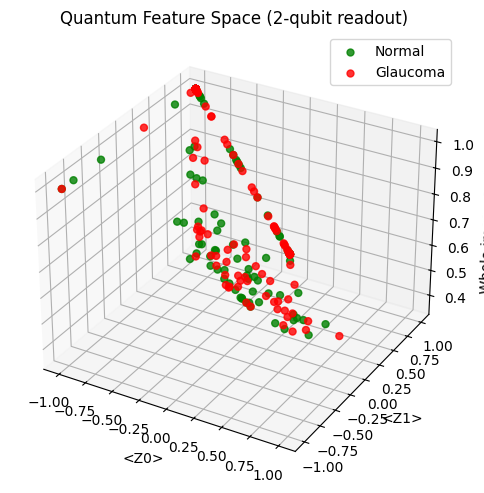

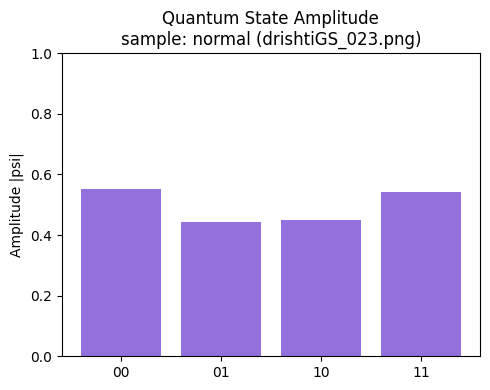

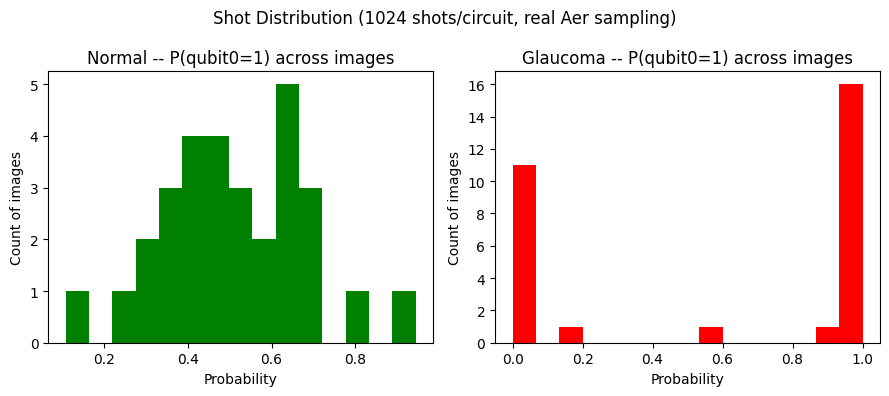

sample                         true label P(q0=1)  confidence level
drishtiGS_023.png              normal     0.49     0.88       High
drishtiGS_093.png              normal     0.41     0.90       High
drishtiGS_021.png              normal     0.64     0.91       High
drishtiGS_078.png              normal     0.40     0.90       High


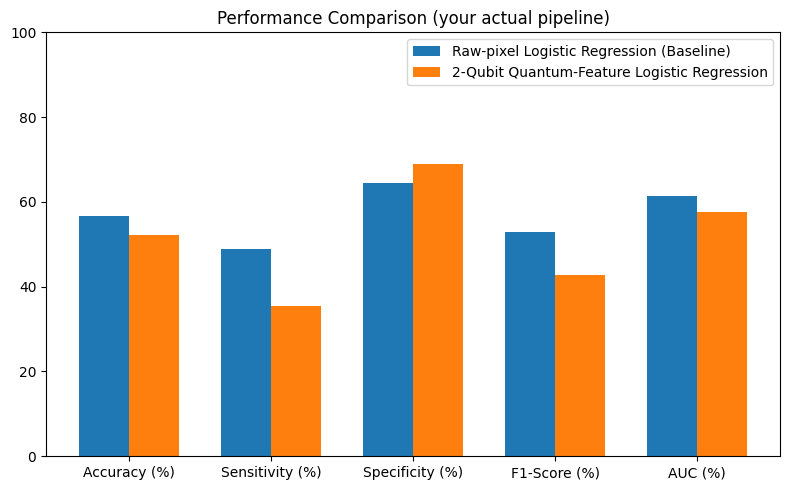

{'pixel_baseline': {'Accuracy': 0.5666666666666667, 'Sensitivity': np.float64(0.4888888887802469), 'Specificity': np.float64(0.6444444443012346), 'F1-Score': 0.5301204819277109, 'AUC': np.float64(0.6143209876543209)}, 'quantum_features': {'Accuracy': 0.5222222222222223, 'Sensitivity': np.float64(0.3555555554765432), 'Specificity': np.float64(0.6888888887358025), 'F1-Score': 0.4266666666666667, 'AUC': np.float64(0.5755555555555556)}}


In [ ]:
#9. RUN EVERYTHING
# ----------------------------------------------------------------------
if __name__ == "__main__":
    normal_paths, glaucoma_paths = find_labeled_images(EXTRACT_DIR, limit_per_class=150)
    records = run_pipeline_over_dataset(normal_paths, glaucoma_paths)
    print(f"Processed {len(records)} images total.")

    plot_quantum_feature_space(records)
    plot_amplitude(records, index=0)
    plot_shot_distributions(records, shots=1024)
    confidence_table(records)
    results = performance_comparison(records)
    print(results)

Found 150 normal, 150 glaucoma images (capped at 150 each)
Processed 300 images total.


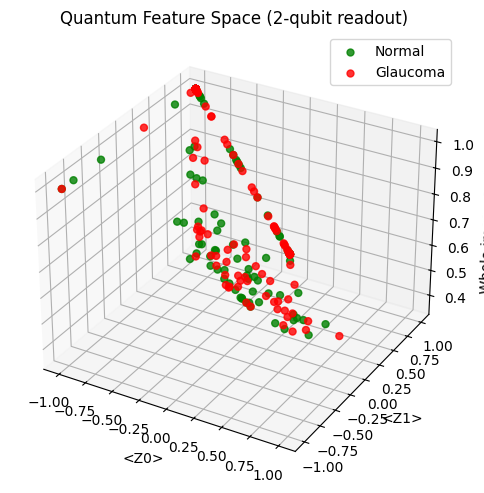

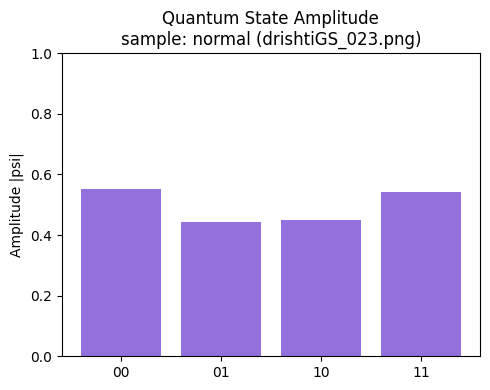

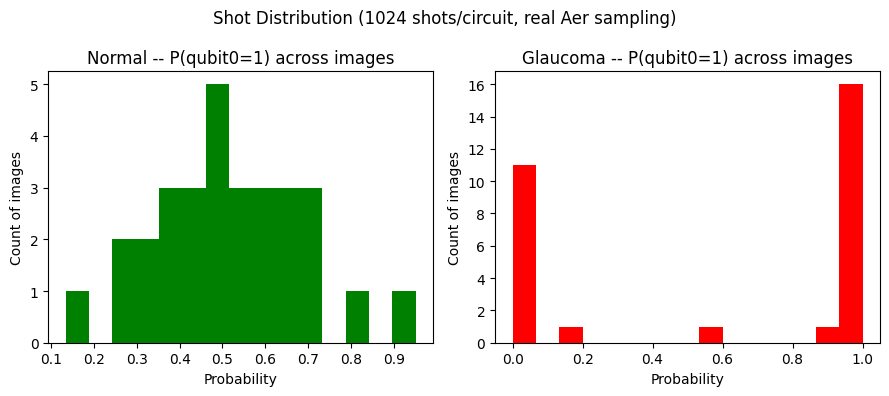

sample                         true label P(q0=1)  confidence level
drishtiGS_023.png              normal     0.48     0.91       High
drishtiGS_093.png              normal     0.42     0.89       High
drishtiGS_021.png              normal     0.65     0.90       High
drishtiGS_078.png              normal     0.39     0.89       High


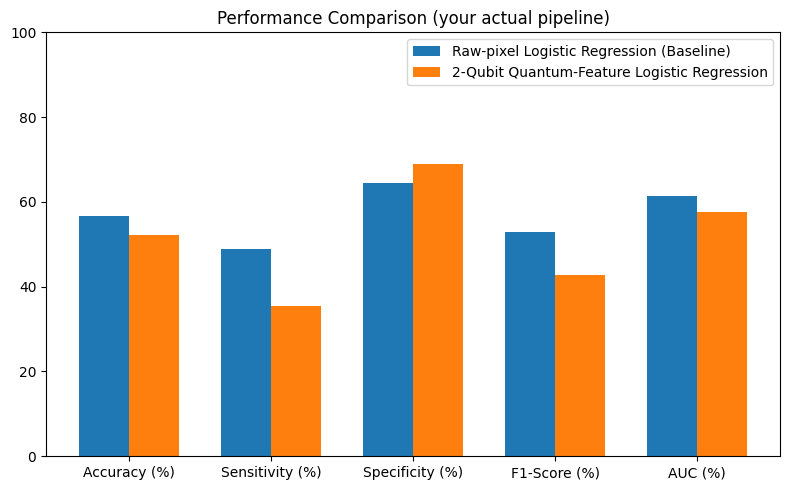

{'pixel_baseline': {'Accuracy': 0.5666666666666667, 'Sensitivity': np.float64(0.4888888887802469), 'Specificity': np.float64(0.6444444443012346), 'F1-Score': 0.5301204819277109, 'AUC': np.float64(0.6143209876543209)}, 'quantum_features': {'Accuracy': 0.5222222222222223, 'Sensitivity': np.float64(0.3555555554765432), 'Specificity': np.float64(0.6888888887358025), 'F1-Score': 0.4266666666666667, 'AUC': np.float64(0.5755555555555556)}}


In [ ]:
# 9. RUN EVERYTHING (Modified for direct execution)
# ----------------------------------------------------------------------
# Regenerate records. Note: This duplicates the records generation in cell GfDA1X9IE64r,
# but ensures this block is fully self-contained if run independently.
normal_paths, glaucoma_paths = find_labeled_images(EXTRACT_DIR, limit_per_class=150)
records = run_pipeline_over_dataset(normal_paths, glaucoma_paths)
print(f"Processed {len(records)} images total.")

plot_quantum_feature_space(records)
plot_amplitude(records, index=0)
plot_shot_distributions(records, shots=1024)
confidence_table(records)
results = performance_comparison(records)
print(results)


In [ ]:
import zipfile
from google.colab import files

output_files = ['quantum_feature_space.png', 'amplitude.png',
                 'shot_distribution.png', 'comparison.png']

with zipfile.ZipFile('my_outputs.zip', 'w') as zf:
    for f in output_files:
        zf.write(f)

files.download('my_outputs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import zipfile
import os
import pandas as pd
from google.colab import files

# ---- Save table-type outputs that don't auto-save ----
angle_table.to_csv('angle_table.csv')  # from cell 12

rows = confidence_table(records)
conf_df = pd.DataFrame(rows, columns=['sample', 'true_label', 'P(q0=1)', 'confidence', 'level'])
conf_df.to_csv('confidence_table.csv', index=False)

with open('performance_results.txt', 'w') as f:
    f.write(str(results))

# ---- Full list of every output across all steps ----
output_files = [
    '01_preprocessing_steps.png',
    '02_selected_features.png',
    '03_ry_circuit.png',
    '04_bloch_no_entanglement.png',
    '05_entangled_circuit.png',
    '06_bloch_entangled.png',
    '07_measurement_expectations.png',
    'angle_table.csv',
    'quantum_feature_space.png',
    'amplitude.png',
    'shot_distribution.png',
    'comparison.png',
    'confidence_table.csv',
    'performance_results.txt',
]

existing_files = [f for f in output_files if os.path.exists(f)]
missing_files = [f for f in output_files if not os.path.exists(f)]

with zipfile.ZipFile('all_outputs.zip', 'w') as zf:
    for f in existing_files:
        zf.write(f)

print(f"Zipped {len(existing_files)} files:")
for f in existing_files:
    print(f"  ✓ {f}")
if missing_files:
    print(f"\nSkipped (not generated yet — run the corresponding cell first):")
    for f in missing_files:
        print(f"  ✗ {f}")

files.download('all_outputs.zip')

sample                         true label P(q0=1)  confidence level
drishtiGS_023.png              normal     0.50     0.88       High
drishtiGS_093.png              normal     0.41     0.85       High
drishtiGS_021.png              normal     0.64     0.87       High
drishtiGS_078.png              normal     0.40     0.90       High
Zipped 7 files:
  ✓ angle_table.csv
  ✓ quantum_feature_space.png
  ✓ amplitude.png
  ✓ shot_distribution.png
  ✓ comparison.png
  ✓ confidence_table.csv
  ✓ performance_results.txt

Skipped (not generated yet — run the corresponding cell first):
  ✗ 01_preprocessing_steps.png
  ✗ 02_selected_features.png
  ✗ 03_ry_circuit.png
  ✗ 04_bloch_no_entanglement.png
  ✗ 05_entangled_circuit.png
  ✗ 06_bloch_entangled.png
  ✗ 07_measurement_expectations.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>